In [3]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [71]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [5]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches
from tqdm import tqdm


In [6]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [22]:
extent = [138.5,143,-67,-65.6]
extent_ea=[90,180,-80,-60]

In [25]:
elevation_ = GEBCO(coarsen_factor=40).ds.elevation
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))

In [ ]:
region = Region('Adelie',extent,elevation=elevation,min_elevation=-1000)

In [47]:
sla_ = SLA(deg=0.25).da

In [48]:
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__

In [49]:
winds_ = xr.open_dataset('ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da

In [51]:
sla = region.crop_da(sla_)
sice = region.crop_da(sice_)
winds = region.crop_da(winds_)

Rendering..


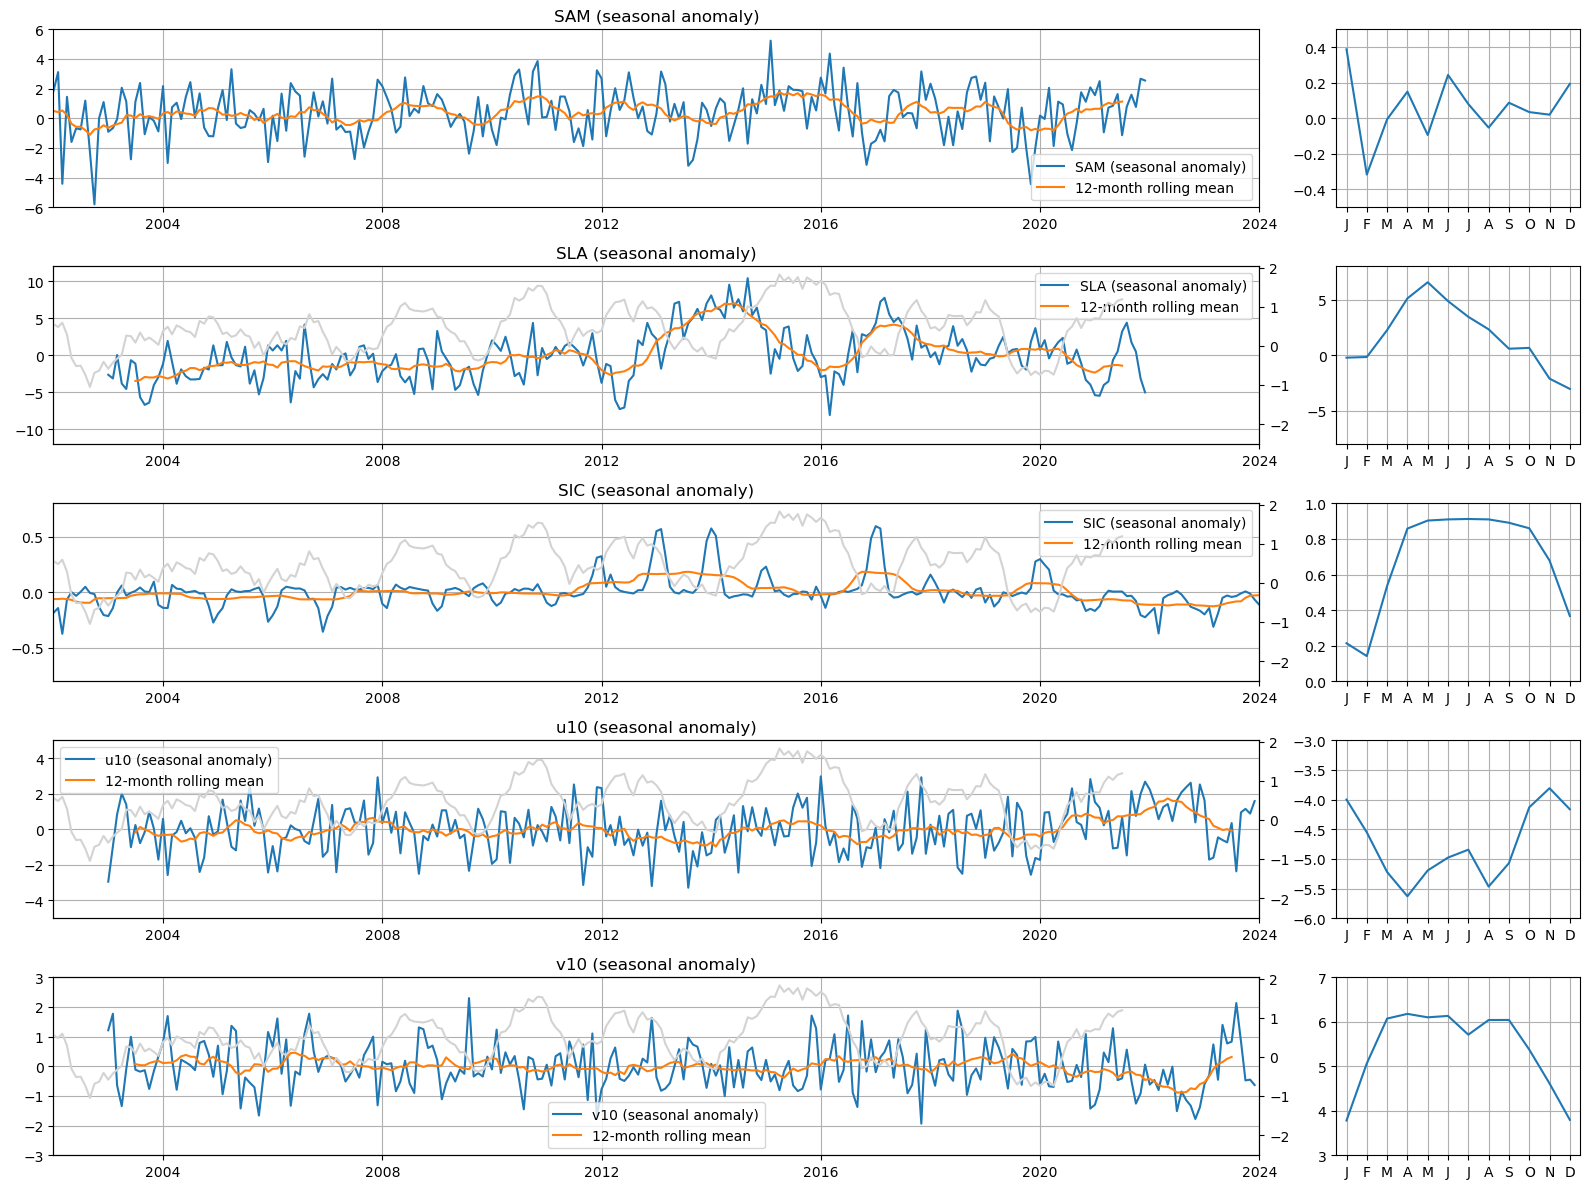

In [45]:
fig = plt.figure(figsize=(16,12))
axs=[]

gs = fig.add_gridspec(5,5)

def add_row(n,var,varname,ylim=[-16,16],ylim_cmt=[-7,7],anom=False):

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if not varname == 'SAM':
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        
    cmt = da.groupby('time.month').mean()

    ax = axs[(n*2)]

    if anom:
        da = da.groupby('time.month') - cmt
        varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname)
    ax.plot(da.time,da.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    ax.set_title(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])

add_row(0,sam,'SAM',anom=True,ylim=[-6,6],ylim_cmt=[-0.5,0.5])
add_row(1,sla,'SLA',anom=True,ylim=[-12,12],ylim_cmt=[-8,8])
add_row(2,sice,'SIC',anom=True,ylim=[-0.8,0.8],ylim_cmt=[0,1])
add_row(3,winds.u10,'u10',anom=True,ylim=[-5,5],ylim_cmt=[-6,-3])
add_row(4,winds.v10,'v10',anom=True,ylim=[-3,3],ylim_cmt=[3,7])

[axs.twinx().plot(sam.time,sam.rolling(time=12,center=True).mean(),c='lightgrey') for axs in [axs[2],axs[4],axs[6],axs[8]]]


plt.tight_layout()
print('Rendering..')


NameError: name 'sla_' is not defined

In [83]:
region = Region('EA',extent_ea)
sla = region.crop_da(sla_)
sice = region.crop_da(sice_)
winds = region.crop_da(winds_)

In [56]:
xr.corr(sla,sam,dim='time')

<xarray.DataArray (latitude: 81, longitude: 360)> Size: 233kB
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [-0.00987547, -0.0296158 , -0.04553009, ...,  0.14647868,
         0.14732561,  0.13918355],
       [ 0.02601377,  0.00145883, -0.01381081, ...,  0.17312227,
         0.16664151,  0.14221151],
       [ 0.04318497,  0.03148817,  0.0307401 , ...,  0.13426619,
         0.13627313,  0.1227261 ]])
Coordinates:
  * longitude  (longitude) float64 3kB 90.0 90.25 90.5 ... 179.2 179.5 179.8
  * latitude   (latitude) float64 648B -80.0 -79.75 -79.5 ... -60.5 -60.25 -60.0

In [65]:
ax[0][0]

<GeoAxes: >

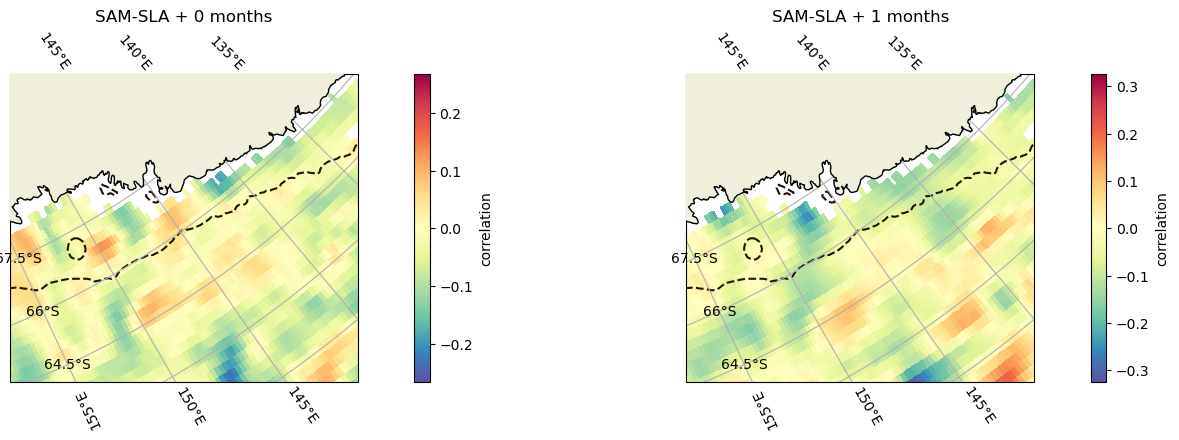

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(16,4),subplot_kw={'projection':ccrs.SouthPolarStereo()})
ext=[135,155,-68,-64]
    sla_lag = sla
    sla_lag['time'] = pd.to_datetime(sla_lag.time.values) + pd.DateOffset(months=i)
    pfns.sp(ax,xr.corr(sla,sam,dim='time'),extent=ext,cbar='correlation',cbar_orientation='vertical',title='SAM-SLA + {} months'.format(i),bathy=elevation_)
